# 4. Baseline Models

Before training any complex model, we establish a performance floor using three simple baselines. The baselines define the minimum acceptable bar.

The data is split strictly by time: training on June and August, validation on October for tuning Ridge regularization, and a single held-out test on December. We never shuffle the data for time series prediction, future observations must not appear in training.

Three baselines are evaluated across all 12 forecast horizons (t+30min to t+6h). B1 Persistence uses the current delay as the prediction for all future steps. B2 Historical Mean looks up the average delay for the target hour and day-of-week from training data. B3 Ridge trains a regularized linear model separately per horizon using all 26 features. Targets are continuous delay values in minutes; disruption alerts are derived afterward by thresholding at 10 minutes.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model  import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})


FEATURE_COLS = [
    'mean_delay', 'std_delay', 'pct_disrupted',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_6', 'lag_12', 'lag_48',
    'delay_trend',
    'hour', 'day_of_week', 'is_weekend', 'is_rush', 'month_num',
    'temperature_c', 'precipitation', 'windspeed_kmh', 'is_raining',
    'event_prospect_park', 'event_livingston', 'event_bergen',
    'event_cadman', 'event_plaza_st', 'event_any',
]
HORIZONS       = list(range(1, 13))
TARGET_COLS    = [f'mean_delay_t{h}' for h in HORIZONS]
TRAIN_MONTHS   = ['Jun', 'Aug']
VAL_MONTH      = 'Oct'
TEST_MONTH     = 'Dec'
DISRUPTION_THR = 10
RIDGE_ALPHAS   = [0.01, 0.1, 1.0, 10.0, 100.0]

df = pd.read_csv('B41_features.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

train = df[df['month'].isin(TRAIN_MONTHS)].copy()
val   = df[df['month'] == VAL_MONTH].copy()
test  = df[df['month'] == TEST_MONTH].copy()
tv    = df[df['month'].isin(TRAIN_MONTHS + [VAL_MONTH])].copy()

print(f'Total rows : {len(df):,}')
print(f'Features   : {len(FEATURE_COLS)}')
print(f'Horizons   : {len(HORIZONS)} (t+30min to t+6h)')
print(f'Train      : {len(train):,} rows  ({", ".join(TRAIN_MONTHS)})')
print(f'Val        : {len(val):,} rows  ({VAL_MONTH})')
print(f'Test       : {len(test):,} rows  ({TEST_MONTH})')
print()
print('Disruption rate per split (mean across all 12 horizons):')
for name, sp in [('Train', train), ('Val', val), ('Test', test)]:
    rate = np.mean([(sp[f'mean_delay_t{h}'] > DISRUPTION_THR).mean() for h in HORIZONS])
    print(f'  {name}: {rate:.1%}')

Total rows : 5,488
Features   : 26
Horizons   : 12 (t+30min to t+6h)
Train      : 2,674 rows  (Jun, Aug)
Val        : 1,411 rows  (Oct)
Test       : 1,403 rows  (Dec)

Disruption rate per split (mean across all 12 horizons):
  Train: 26.7%
  Val: 26.9%
  Test: 24.4%


## Evaluation

The `evaluate()` function computes MAE, RMSE, and R² as regression metrics, plus disruption detection metrics derived by thresholding both predicted and actual values at 10 minutes. This gives precision, recall, and F1 for disruption detection without training a separate classifier. The same function is reused for all three baselines across all 12 horizons.

In [13]:
def evaluate(y_true, y_pred, model_name, horizon, split):
    """Regression + derived disruption-detection metrics for one horizon."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    # Disruption detection by thresholding regression output
    d_true = (np.array(y_true) > DISRUPTION_THR).astype(int)
    d_pred = (np.array(y_pred) > DISRUPTION_THR).astype(int)
    prec = d_true[d_pred == 1].mean() if d_pred.sum() > 0 else 0.0
    rec  = d_pred[d_true == 1].mean() if d_true.sum() > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return {
        'model': model_name, 'horizon': horizon,
        'horizon_min': horizon * 30, 'split': split,
        'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R2': round(r2, 3),
        'F1': round(f1, 3), 'Precision': round(prec, 3), 'Recall': round(rec, 3),
    }

results      = []
ridge_models = {} 

## B1 — Persistence

The simplest possible baseline: predict that future delay equals whatever the delay is right now, copied forward for all 12 horizons. No training is required.

This works reasonably well at short horizons because delays are autocorrelated. The current route state is informative about the near future. But autocorrelation decays with time, so persistence degrades steadily as the horizon grows.

In [14]:
for split_name, split_df in [('val', val), ('test', test)]:
    y_persist = split_df['mean_delay'].values
    for h in HORIZONS:
        y_true = split_df[f'mean_delay_t{h}'].values
        results.append(evaluate(y_true, y_persist, 'B1_Persistence', h, split_name))

B1 = pd.DataFrame([r for r in results if r['model'] == 'B1_Persistence'])
pivot = B1.pivot_table(index='horizon_min', columns='split', values='MAE').round(3)
pivot.index = [f't+{m}min' for m in pivot.index]
print('B1 Persistence — MAE by horizon:')
print(pivot.to_string())

B1 Persistence — MAE by horizon:
split      test    val
t+30min   1.684  1.795
t+60min   2.336  2.335
t+90min   2.852  2.661
t+120min  3.244  3.003
t+150min  3.634  3.315
t+180min  3.982  3.601
t+210min  4.293  3.852
t+240min  4.586  4.032
t+270min  4.823  4.315
t+300min  5.071  4.522
t+330min  5.321  4.731
t+360min  5.578  4.945


Persistence is strongest at t+30min (MAE 1.68 min) and deteriorates steadily to 5.58 min at t+6h. The near-linear decay reflects how autocorrelation weakens with lag. This gives us a clear target: any model predicting more than a few steps ahead needs to substantially beat these numbers to be considered useful.

## B2 — Historical Mean (Seasonal Naive)

Rather than using the current state, this baseline looks up the historical average delay for the time slot being predicted, specifically the (hour × day-of-week) combination of the target timestamp, not the current one.

The distinction matters at long horizons. A prediction made at 10:00 for 16:00 should use the evening rush pattern, not the mid-morning pattern. The lookup table is built from training data only for validation, and from training plus validation combined for the final test evaluation.

In [15]:
def hist_mean_predict(df_lookup, df_pred, target, h):
    """Predict mean delay using (target_hour × target_dow) lookup from df_lookup."""
    td = pd.Timedelta(minutes=h * 30)

    lk = df_lookup.copy()
    lk['target_hour'] = (lk['timestamp'] + td).dt.hour
    lk['target_dow']  = (lk['timestamp'] + td).dt.dayofweek
    lookup = (lk.groupby(['target_hour', 'target_dow'])[target]
                .mean().reset_index()
                .rename(columns={target: 'hist_pred'}))
    fallback = lk[target].mean()

    pr = df_pred[['timestamp', target]].copy()
    pr['target_hour'] = (pr['timestamp'] + td).dt.hour
    pr['target_dow']  = (pr['timestamp'] + td).dt.dayofweek
    pr = pr.merge(lookup, on=['target_hour', 'target_dow'], how='left')
    pr['hist_pred'] = pr['hist_pred'].fillna(fallback)
    return pr['hist_pred'].values


for h in HORIZONS:
    target = f'mean_delay_t{h}'
    # Val
    results.append(evaluate(val[target].values,
                             hist_mean_predict(train, val, target, h),
                             'B2_HistMean', h, 'val'))
    # Test
    results.append(evaluate(test[target].values,
                             hist_mean_predict(tv, test, target, h),
                             'B2_HistMean', h, 'test'))

B2 = pd.DataFrame([r for r in results if r['model'] == 'B2_HistMean'])
pivot = B2.pivot_table(index='horizon_min', columns='split', values='MAE').round(3)
pivot.index = [f't+{m}min' for m in pivot.index]
print('B2 Historical Mean — MAE by horizon:')
print(pivot.to_string())

B2 Historical Mean — MAE by horizon:
split      test    val
t+30min   3.020  2.795
t+60min   3.026  2.802
t+90min   3.028  2.804
t+120min  3.028  2.810
t+150min  3.026  2.811
t+180min  3.025  2.810
t+210min  3.034  2.807
t+240min  3.035  2.808
t+270min  3.036  2.807
t+300min  3.040  2.805
t+330min  3.039  2.810
t+360min  3.038  2.814


Historical Mean shows almost completely flat MAE across all horizons. Around 3.0 minutes whether predicting 30 minutes or 6 hours ahead. This is expected: the lookup depends only on calendar patterns, which are equally well-known at any horizon. The flat profile acts as a natural reference line. It marks the level of accuracy achievable from time-of-day structure alone, with no information about the current route state.

## B3 — Ridge Regression (Direct Multi-Step)

Ridge uses all 26 features and is trained separately for each of the 12 horizons. Training one model per horizon rather than recursively chaining a single model avoids error accumulation. Each model is optimized directly for its target horizon without depending on the accuracy of earlier predictions.

Features are standardized before training. Regularization strength (alpha) is selected per horizon by comparing validation MAE across five candidate values. The final model is retrained on train+val combined before test evaluation.

In [16]:
# Standardization
scaler_tr = StandardScaler().fit(train[FEATURE_COLS].values)
X_train_s = scaler_tr.transform(train[FEATURE_COLS].values)
X_val_s   = scaler_tr.transform(val[FEATURE_COLS].values)

scaler_tv = StandardScaler().fit(tv[FEATURE_COLS].values)
X_tv_s    = scaler_tv.transform(tv[FEATURE_COLS].values)
X_test_s  = scaler_tv.transform(test[FEATURE_COLS].values)

best_alphas = {}

for h in HORIZONS:
    target  = f'mean_delay_t{h}'
    y_train = train[target].values
    y_val   = val[target].values
    y_tv    = tv[target].values
    y_test  = test[target].values

    
    best_alpha, best_val_mae = None, np.inf
    for alpha in RIDGE_ALPHAS:
        pred = Ridge(alpha=alpha).fit(X_train_s, y_train).predict(X_val_s)
        mae  = mean_absolute_error(y_val, pred)
        if mae < best_val_mae:
            best_val_mae, best_alpha = mae, alpha
    best_alphas[h] = best_alpha

    # Val metrics 
    val_pred = Ridge(alpha=best_alpha).fit(X_train_s, y_train).predict(X_val_s)
    results.append(evaluate(y_val, val_pred, 'B3_Ridge', h, 'val'))

    # Final model
    final_model = Ridge(alpha=best_alpha).fit(X_tv_s, y_tv)
    test_pred   = final_model.predict(X_test_s)
    results.append(evaluate(y_test, test_pred, 'B3_Ridge', h, 'test'))
    ridge_models[h] = (final_model, scaler_tv)

print('Best alphas per horizon:')
for h in HORIZONS:
    print(f'  t+{h*30}min: α={best_alphas[h]}')

B3 = pd.DataFrame([r for r in results if r['model'] == 'B3_Ridge'])
pivot = B3.pivot_table(index='horizon_min', columns='split', values='MAE').round(3)
pivot.index = [f't+{m}min' for m in pivot.index]
print()
print('B3 Ridge — MAE by horizon:')
print(pivot.to_string())

Best alphas per horizon:
  t+30min: α=100.0
  t+60min: α=100.0
  t+90min: α=100.0
  t+120min: α=100.0
  t+150min: α=100.0
  t+180min: α=100.0
  t+210min: α=100.0
  t+240min: α=100.0
  t+270min: α=100.0
  t+300min: α=100.0
  t+330min: α=100.0
  t+360min: α=100.0

B3 Ridge — MAE by horizon:
split      test    val
t+30min   1.648  1.824
t+60min   2.228  2.437
t+90min   2.644  2.833
t+120min  3.006  3.181
t+150min  3.281  3.580
t+180min  3.499  3.937
t+210min  3.640  4.172
t+240min  3.721  4.370
t+270min  3.758  4.617
t+300min  3.753  4.880
t+330min  3.743  5.088
t+360min  3.726  5.219


Alpha=100 was selected for every horizon. The maximum value in the search grid, which suggests the true optimal alpha may be even higher and the grid should be extended. Heavy regularization means predictions are pulled strongly toward the global mean, which will be visible in the scatter plots as a compression of the predicted range at long horizons.

## Results

In [17]:
results_df = pd.DataFrame(results)

# MAE table — test set
test_df = results_df[results_df['split'] == 'test']
mae_table = (
    test_df.pivot_table(index='horizon_min', columns='model', values='MAE')
           [['B1_Persistence', 'B2_HistMean', 'B3_Ridge']]
           .round(3)
)
mae_table.index = [f't+{m}min' for m in mae_table.index]

print('=' * 55)
print('MAE by Model and Horizon — Test Set (December)')
print('=' * 55)
print(mae_table.to_string())
print()
print('Average MAE across all 12 horizons:')
print(mae_table.mean().round(3).to_string())

print()
# F1 table — disruption detection (threshold at 10 min)
f1_table = (
    test_df.pivot_table(index='horizon_min', columns='model', values='F1')
           [['B1_Persistence', 'B2_HistMean', 'B3_Ridge']]
           .round(3)
)
f1_table.index = [f't+{m}min' for m in f1_table.index]
print('=' * 55)
print('Disruption Detection F1 (threshold at 10 min) — Test Set')
print('=' * 55)
print(f1_table.to_string())
print()
print('Average F1 across all 12 horizons:')
print(f1_table.mean().round(3).to_string())

MAE by Model and Horizon — Test Set (December)
model     B1_Persistence  B2_HistMean  B3_Ridge
t+30min            1.684        3.020     1.648
t+60min            2.336        3.026     2.228
t+90min            2.852        3.028     2.644
t+120min           3.244        3.028     3.006
t+150min           3.634        3.026     3.281
t+180min           3.982        3.025     3.499
t+210min           4.293        3.034     3.640
t+240min           4.586        3.035     3.721
t+270min           4.823        3.036     3.758
t+300min           5.071        3.040     3.753
t+330min           5.321        3.039     3.743
t+360min           5.578        3.038     3.726

Average MAE across all 12 horizons:
model
B1_Persistence    3.950
B2_HistMean       3.031
B3_Ridge          3.221

Disruption Detection F1 (threshold at 10 min) — Test Set
model     B1_Persistence  B2_HistMean  B3_Ridge
t+30min            0.847        0.625     0.849
t+60min            0.767        0.626     0.739
t+90min     

At t+30min Ridge already beats Persistence slightly (MAE 1.65 vs 1.68) which is a small but real improvement given they use the same data. More notable is how quickly the gap closes, by around t+2.5h Historical Mean catches up, and from there all three models are essentially tied. Past the 2-3 hour mark, knowing the current delay state adds very little; the time-of-day calendar is about all that can be predicted from these features.

## Visualisations

### MAE vs Forecast Horizon

The left panel compares all three baselines on the test set across all horizons. The right panel checks how well Ridge generalizes by comparing its val (October) and test (December) MAE. Large gap would signal overfitting to the training months.

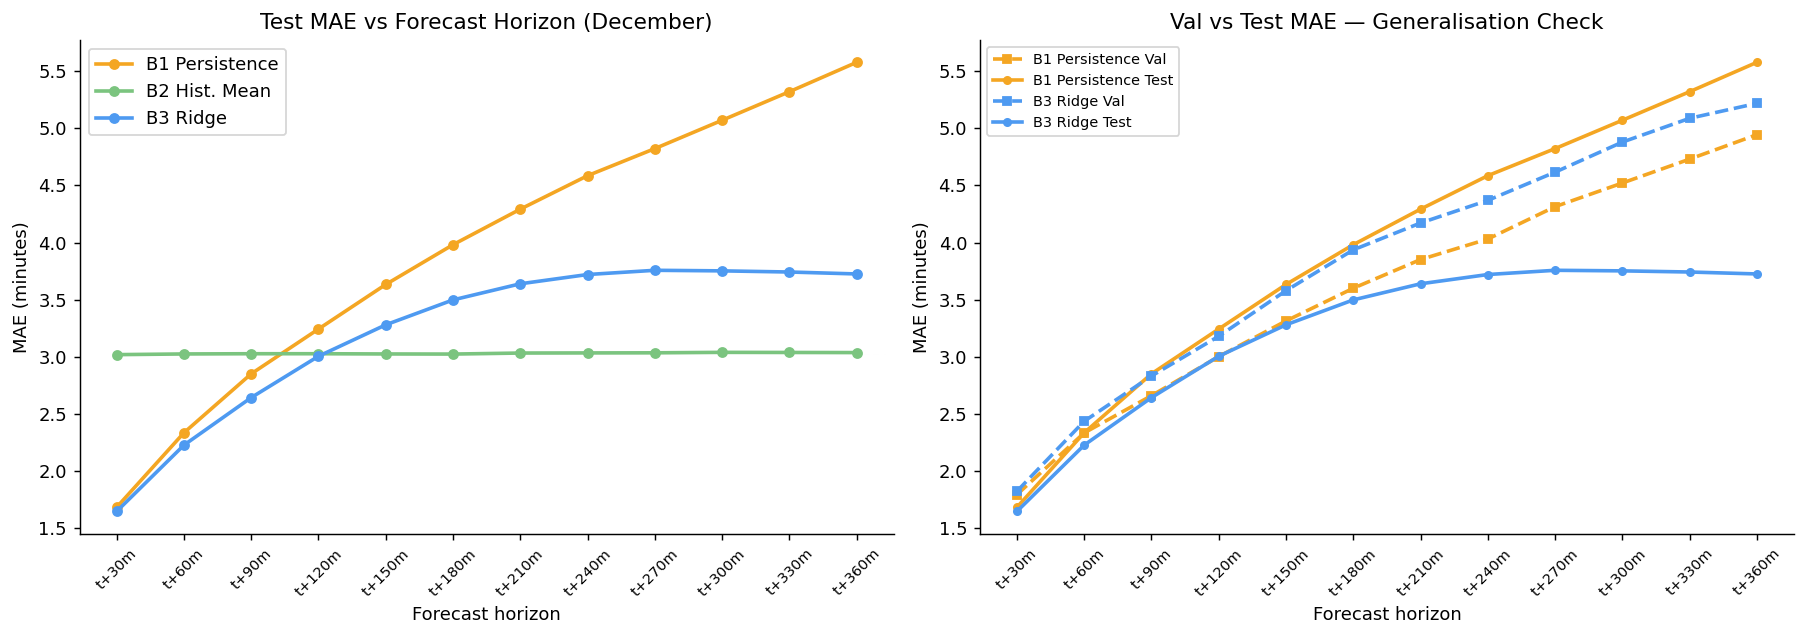

In [18]:
colors = {'B1_Persistence': '#f4a623', 'B2_HistMean': '#7bc47f', 'B3_Ridge': '#4e9af1'}
labels = {'B1_Persistence': 'B1 Persistence', 'B2_HistMean': 'B2 Hist. Mean', 'B3_Ridge': 'B3 Ridge'}
xticks = [h * 30 for h in HORIZONS]
xlabels = [f't+{h*30}m' for h in HORIZONS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: test MAE vs horizon for all 3 models
ax = axes[0]
for model, color in colors.items():
    sub = test_df[test_df['model'] == model].sort_values('horizon_min')
    ax.plot(sub['horizon_min'], sub['MAE'], marker='o', color=color,
            linewidth=2, markersize=5, label=labels[model])
ax.set_xlabel('Forecast horizon')
ax.set_ylabel('MAE (minutes)')
ax.set_title('Test MAE vs Forecast Horizon (December)')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=45, fontsize=8)
ax.legend()

# Right: val vs test MAE for Persistence and Ridge (generalisation check)
ax = axes[1]
val_df = results_df[results_df['split'] == 'val']
for model, color in [('B1_Persistence', '#f4a623'), ('B3_Ridge', '#4e9af1')]:
    vv = val_df[val_df['model'] == model].sort_values('horizon_min')
    tt = test_df[test_df['model'] == model].sort_values('horizon_min')
    ax.plot(vv['horizon_min'], vv['MAE'], color=color, linewidth=2,
            linestyle='--', marker='s', markersize=4, label=f'{labels[model]} Val')
    ax.plot(tt['horizon_min'], tt['MAE'], color=color, linewidth=2,
            marker='o', markersize=4, label=f'{labels[model]} Test')
ax.set_xlabel('Forecast horizon')
ax.set_ylabel('MAE (minutes)')
ax.set_title('Val vs Test MAE — Generalisation Check')
ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=45, fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('baseline_mae_horizon.png', bbox_inches='tight')
plt.show()

The crossover around t+150min is the main takeaway from the left panel. The right panel is also reassuring that the gap between val (October) and test (December) performance for Ridge is small across all horizons, meaning the model is not simply memorizing the training months.

### Prediction Scatter

Each panel shows actual vs predicted delay for one horizon on the December test set. Points on the diagonal are perfect predictions. Red dotted lines mark the 10-minute disruption threshold. Points in the top-left quadrant are missed disruptions, bottom-right are false alarms.

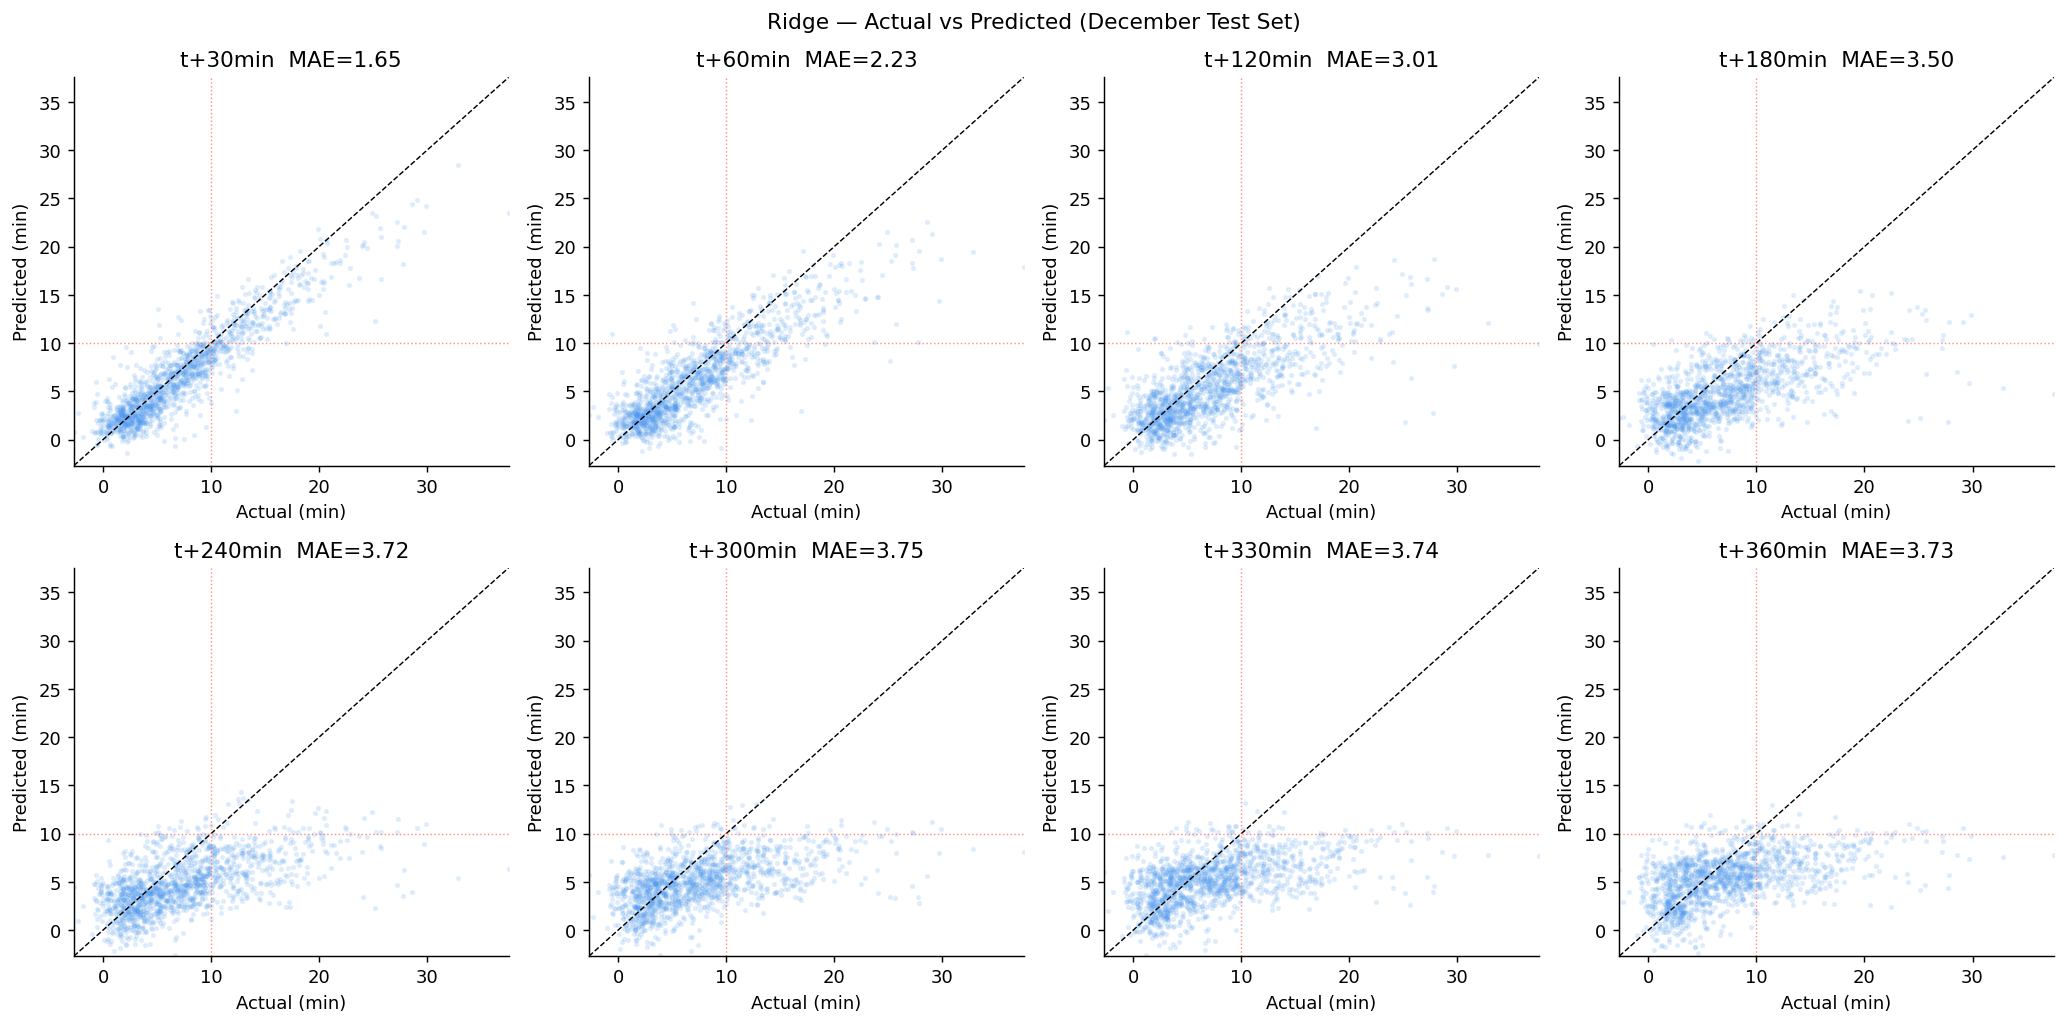

In [19]:
KEY_HORIZONS = [1, 2, 4, 6, 8, 10, 11, 12]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Ridge — Actual vs Predicted (December Test Set)', fontsize=12)

for ax, h in zip(axes.flat, KEY_HORIZONS):
    target = f'mean_delay_t{h}'
    model, scaler = ridge_models[h]
    y_true = test[target].values
    y_pred = model.predict(scaler.transform(test[FEATURE_COLS].values))

    lim = [min(y_true.min(), -2), max(y_true.max(), 25)]
    ax.scatter(y_true, y_pred, alpha=0.12, s=4, color='#4e9af1')
    ax.plot(lim, lim, 'k--', linewidth=0.8)
    ax.axhline(DISRUPTION_THR, color='tomato', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.axvline(DISRUPTION_THR, color='tomato', linestyle=':', linewidth=0.8, alpha=0.7)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f't+{h*30}min  MAE={mean_absolute_error(y_true, y_pred):.2f}')
    ax.set_xlabel('Actual (min)')
    ax.set_ylabel('Predicted (min)')

plt.tight_layout()
plt.savefig('baseline_scatter.png', bbox_inches='tight')
plt.show()

The t+30min panel looks reasonable — predictions spread across the actual range and roughly follow the diagonal. From t+4h onwards the predicted values collapse into a narrow band around 7–9 minutes regardless of what the actual delay is. The model is effectively predicting the average. That is why F1 drops so sharply at long horizons: predictions rarely exceed 10 minutes, so most actual disruptions go undetected.

### Feature Importance — Ridge Coefficients at t+1h vs t+6h

Comparing coefficients across two horizons shows how the model's reliance on different features shifts as prediction horizon increases. Red bars increase predicted delay, blue bars decrease it.

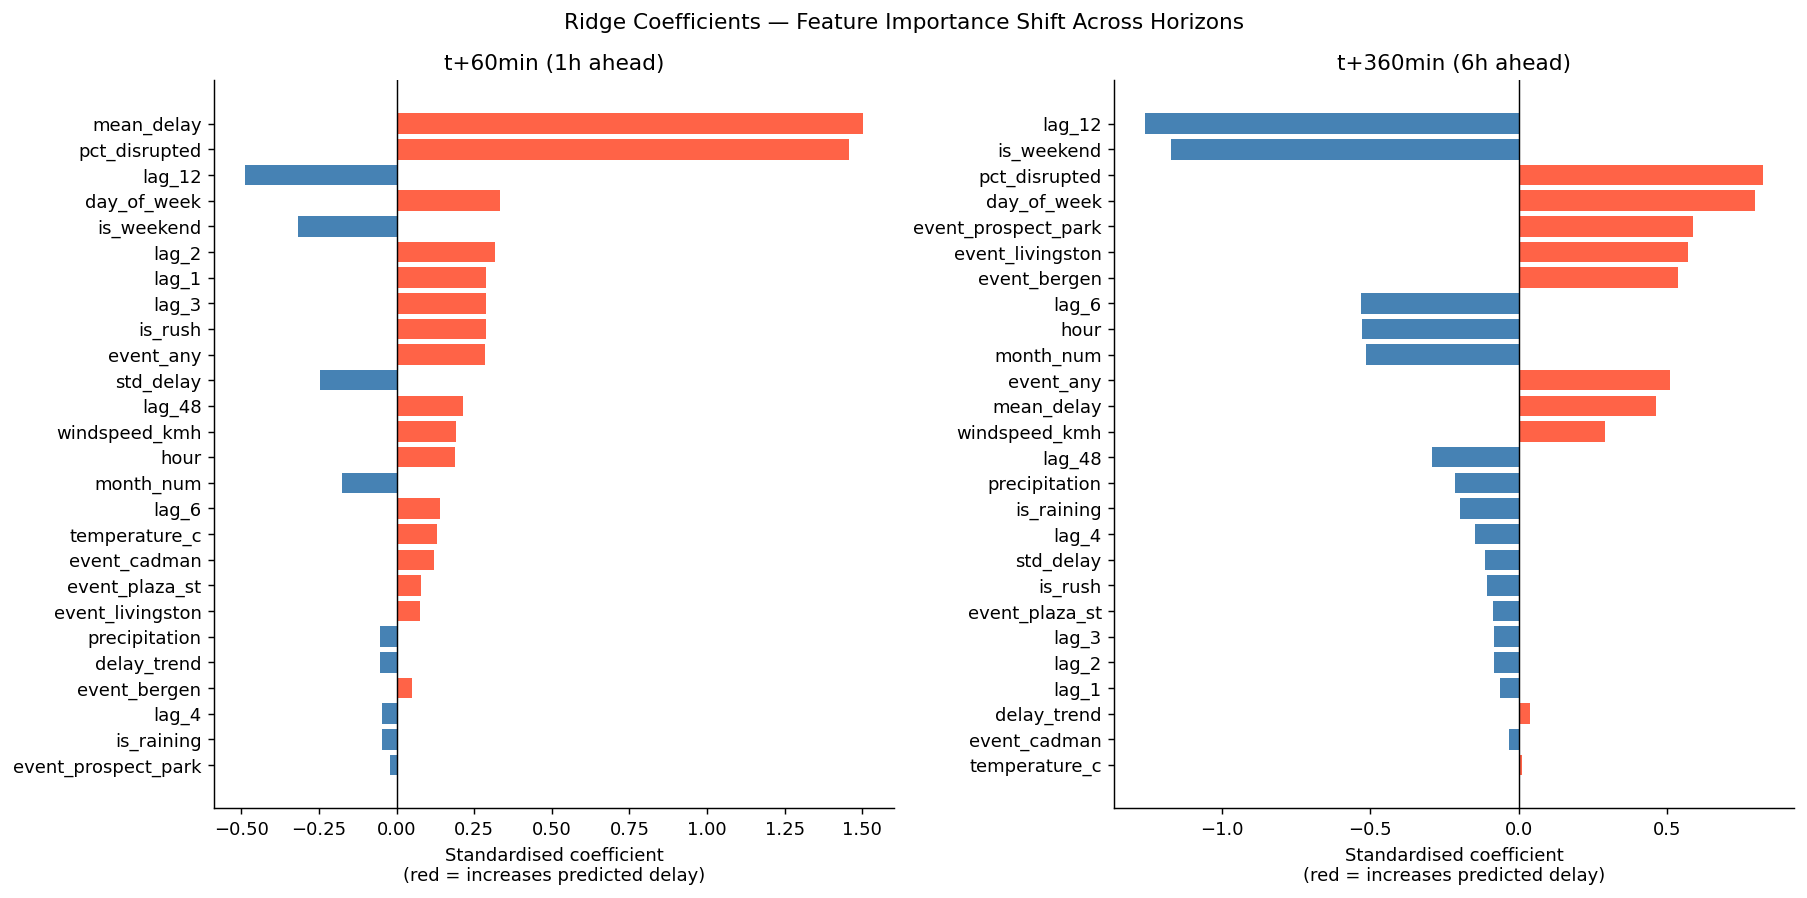

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Ridge Coefficients — Feature Importance Shift Across Horizons', fontsize=12)

for ax, h in zip(axes, [2, 12]):   # t+1h and t+6h
    model, _ = ridge_models[h]
    coef_df  = pd.DataFrame({'feature': FEATURE_COLS, 'coef': model.coef_})
    coef_df  = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)
    bar_colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coef']]
    ax.barh(coef_df['feature'], coef_df['coef'], color=bar_colors, edgecolor='none')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Standardised coefficient\n(red = increases predicted delay)')
    ax.set_title(f't+{h*30}min ({h//2}h ahead)')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('baseline_ridge_coef.png', bbox_inches='tight')
plt.show()

At t+1h it is the lag features that drive predictions. lag_1 and lag_2 stand out clearly. At t+6h that changes: the lag coefficients shrink and calendar features like hour and is_rush take more weight. At long horizons the model ends up doing something similar to Historical Mean, just implicitly through its features rather than a lookup table.

## Save

Test-set metrics are saved to `results_baseline.csv` for direct comparison with LSTM results later.

In [21]:
out = results_df[results_df['split'] == 'test'].copy()
out.to_csv('results_baseline.csv', index=False)

print(f'Rows   : {len(out)}  (3 models × 12 horizons)')
print(f'Columns: {list(out.columns)}')
print()
print('Quick check — Ridge at t+30min and t+6h:')
check = out[out['model'] == 'B3_Ridge'][['horizon_min','MAE','R2','F1']].set_index('horizon_min')
print(check.loc[[30, 360]].to_string())

Rows   : 36  (3 models × 12 horizons)
Columns: ['model', 'horizon', 'horizon_min', 'split', 'MAE', 'RMSE', 'R2', 'F1', 'Precision', 'Recall']

Quick check — Ridge at t+30min and t+6h:
               MAE     R2     F1
horizon_min                     
30           1.648  0.833  0.849
360          3.726  0.101  0.124


### Save Ridge Predictions

Row-level predictions are saved to `predictions_ridge_test.csv` for residual analysis and prediction interval plots in the uncertainty notebook.

In [22]:
pred_rows = []
for h in HORIZONS:
    target = f'mean_delay_t{h}'
    model, scaler = ridge_models[h]
    y_pred = model.predict(scaler.transform(test[FEATURE_COLS].values))
    y_true = test[target].values
    for idx in range(len(test)):
        pred_rows.append({
            'timestamp': test['timestamp'].iloc[idx],
            'horizon': h,
            'horizon_min': h * 30,
            'y_true': round(float(y_true[idx]), 4),
            'y_pred': round(float(y_pred[idx]), 4),
            'residual': round(float(y_true[idx] - y_pred[idx]), 4),
        })

preds_df = pd.DataFrame(pred_rows)
preds_df.to_csv('predictions_ridge_test.csv', index=False)


print(f'Rows   : {len(preds_df):,}  (1,403 test rows × 12 horizons)')
print(f'Columns: {list(preds_df.columns)}')
print()
print('Residual stats per horizon (mean ± std):')
for h in HORIZONS:
    sub = preds_df[preds_df['horizon'] == h]['residual']
    print(f'  t+{h*30:3d}min: mean={sub.mean():+.3f}  std={sub.std():.3f}')


Rows   : 16,836  (1,403 test rows × 12 horizons)
Columns: ['timestamp', 'horizon', 'horizon_min', 'y_true', 'y_pred', 'residual']

Residual stats per horizon (mean ± std):
  t+ 30min: mean=+0.573  std=2.181
  t+ 60min: mean=+1.100  std=2.870
  t+ 90min: mean=+1.478  std=3.363
  t+120min: mean=+1.850  std=3.757
  t+150min: mean=+2.115  std=4.050
  t+180min: mean=+2.354  std=4.263
  t+210min: mean=+2.466  std=4.412
  t+240min: mean=+2.508  std=4.514
  t+270min: mean=+2.474  std=4.624
  t+300min: mean=+2.372  std=4.712
  t+330min: mean=+2.200  std=4.793
  t+360min: mean=+2.003  std=4.825
